# IAM Degraded Dataset Verification
Visually confirms degraded parquets are correct and checks row counts match the raw test set (2915 images).

In [1]:
from datasets import load_dataset
import matplotlib.pyplot as plt

HF_REPO_ID    = "LeMerta/bachelor-thesis-datasets"
EXPECTED_ROWS = 2915

def verify_and_display(method_name, intensities):
    """Load all intensities for a method, display first image of each, check row counts."""
    print(f"\n{method_name}")
    fig, axes = plt.subplots(len(intensities), 1, figsize=(16, 10))
    fig.suptitle(method_name, fontsize=14)

    for ax, intensity in zip(axes, intensities):
        path = f"iam/{method_name}/test/{method_name}_{intensity}.parquet"
        dataset = load_dataset("parquet", data_files=f"hf://datasets/{HF_REPO_ID}/{path}", split="train")

        # Check row count
        status = "OK" if len(dataset) == EXPECTED_ROWS else f"WRONG"
        print(f"  intensity={intensity}: {len(dataset)} rows [{status}]")

        # Display first image
        sample = dataset[0]
        image  = sample["image"].convert("RGB")
        text   = sample["text"]
        ax.imshow(image)
        ax.set_title(f"intensity={intensity} | text: {text}", fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


awgn
  intensity=50: 2915 rows [OK]
  intensity=100: 2915 rows [OK]
  intensity=150: 2915 rows [OK]
  intensity=200: 2915 rows [OK]
  intensity=250: 2915 rows [OK]


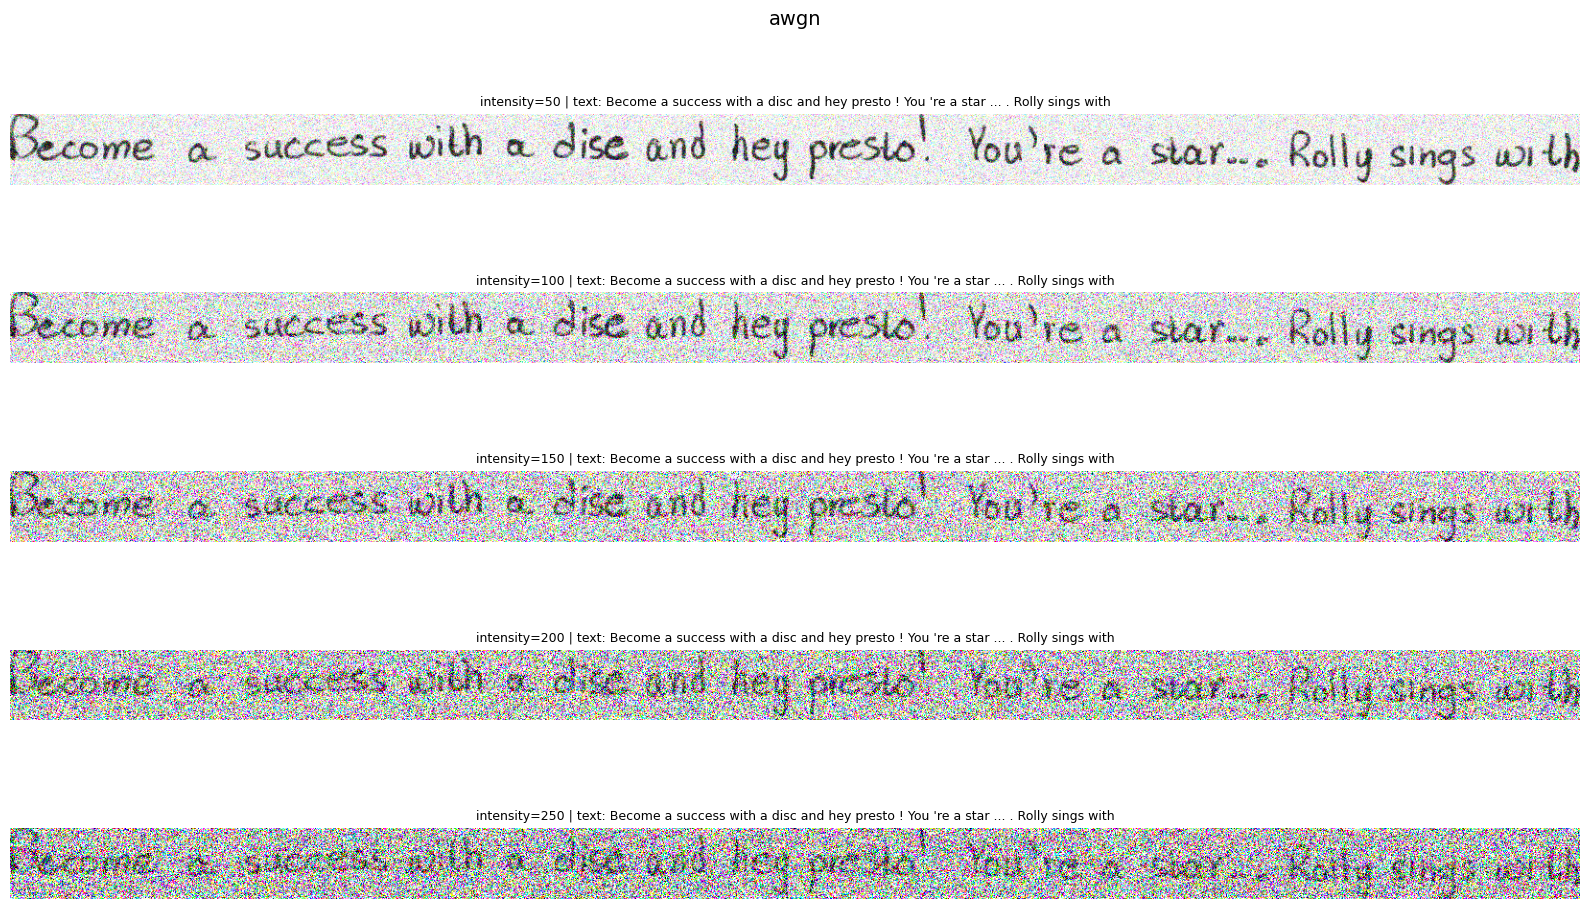

In [2]:
# AWGN
verify_and_display(
    method_name="awgn",
    intensities=[50, 100, 150, 200, 250]
)


blur
  intensity=1.0: 2915 rows [OK]


iam/blur/test/blur_2.0.parquet:   0%|          | 0.00/158M [00:00<?, ?B/s]

c:\Users\Lennard\.conda\envs\bachelor-thesis\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Lennard\.cache\huggingface\hub\datasets--LeMerta--bachelor-thesis-datasets. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Generating train split: 0 examples [00:00, ? examples/s]

  intensity=2.0: 2915 rows [OK]


...

Generating train split: 0 examples [00:00, ? examples/s]

  intensity=4.0: 2915 rows [OK]


iam/blur/test/blur_5.0.parquet:   0%|          | 0.00/129M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

  intensity=5.0: 2915 rows [OK]


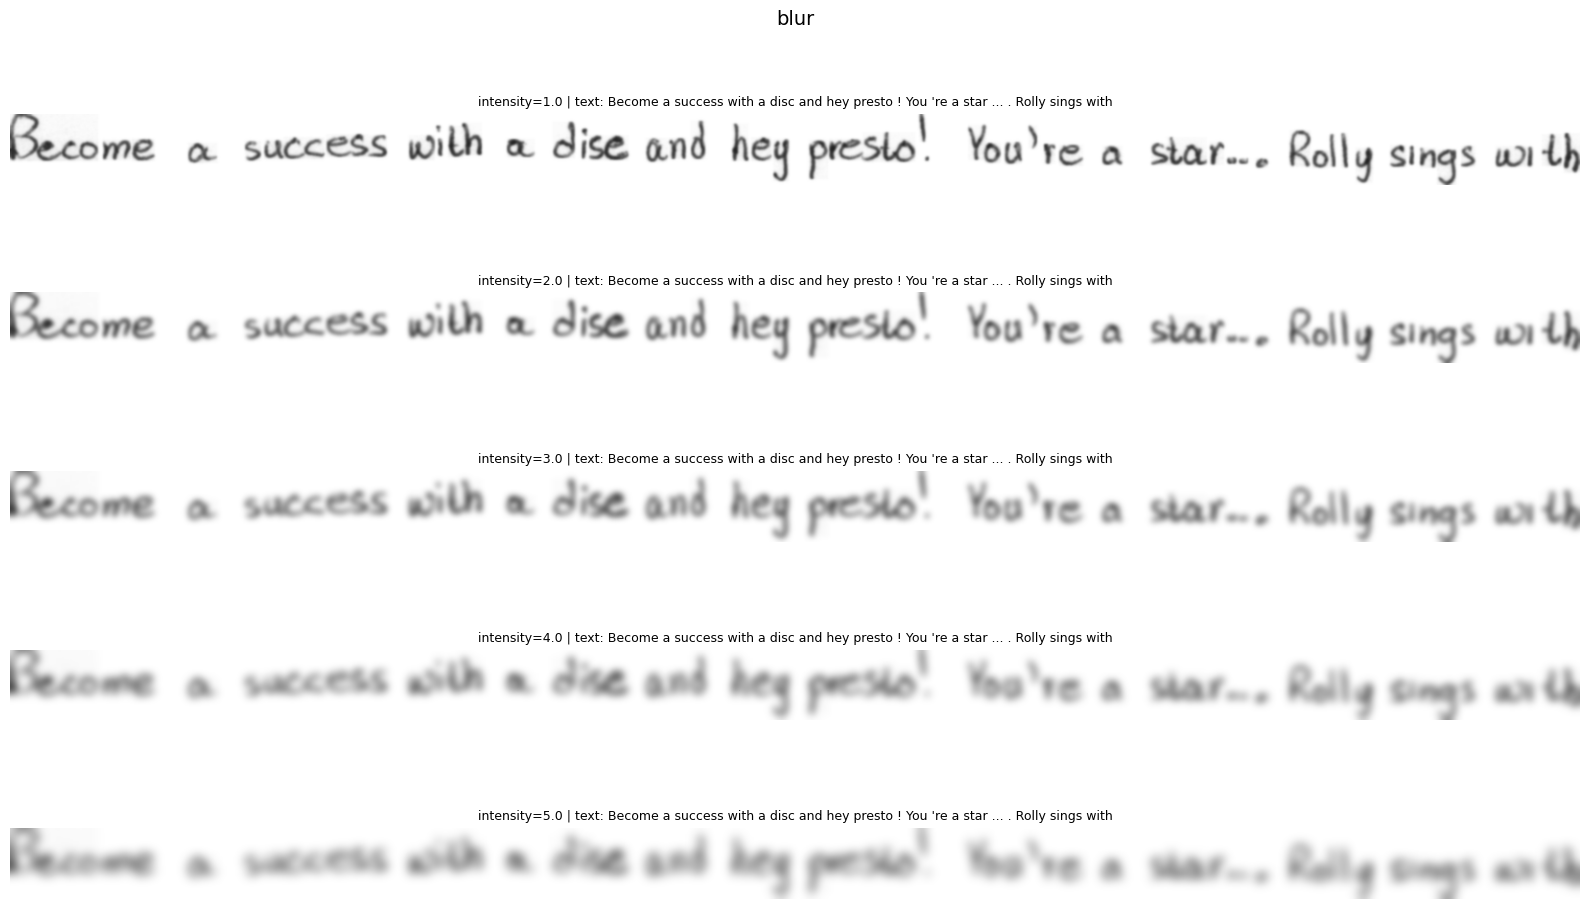

In [3]:
# Gaussian Blur
verify_and_display(
    method_name="blur",
    intensities=[1.0, 2.0, 3.0, 4.0, 5.0]
)


jpeg_compression


iam/jpeg_compression/test/jpeg_compressi(…):   0%|          | 0.00/219M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

  intensity=10: 2915 rows [OK]


iam/jpeg_compression/test/jpeg_compressi(…):   0%|          | 0.00/201M [00:00<?, ?B/s]

...

Generating train split: 0 examples [00:00, ? examples/s]

  intensity=3: 2915 rows [OK]


iam/jpeg_compression/test/jpeg_compressi(…):   0%|          | 0.00/140M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

  intensity=1: 2915 rows [OK]


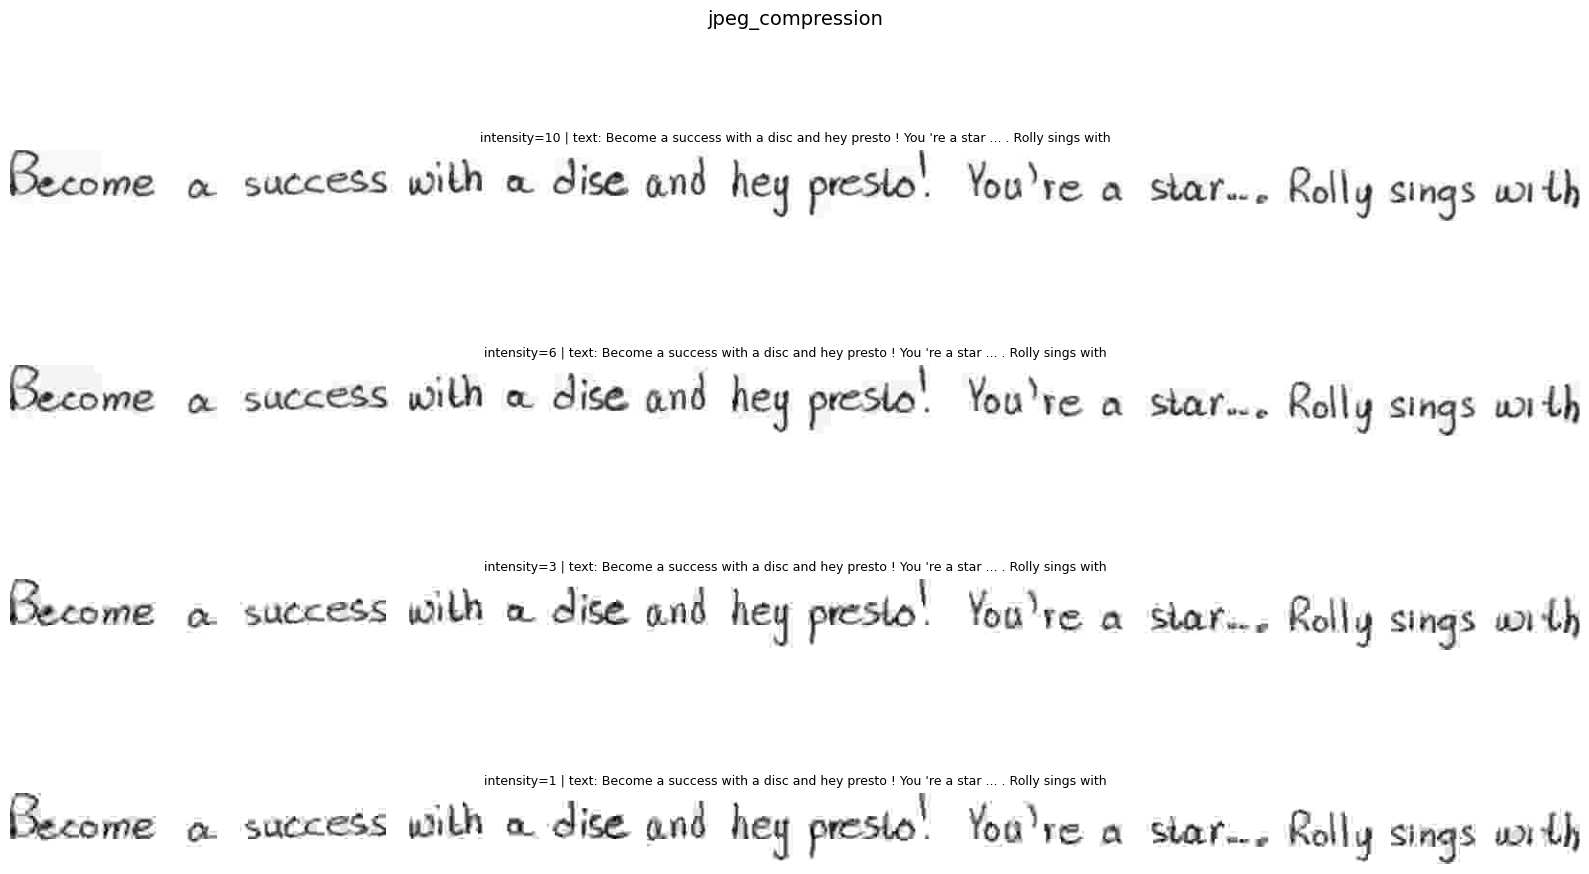

In [5]:
# JPEG Compression
verify_and_display(
    method_name="jpeg_compression",
    intensities=[10, 6, 3, 1]
)


downscale


iam/downscale/test/downscale_0.4.parquet:   0%|          | 0.00/224M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

  intensity=0.4: 2915 rows [OK]


iam/downscale/test/downscale_0.3.parquet:   0%|          | 0.00/208M [00:00<?, ?B/s]

...

Generating train split: 0 examples [00:00, ? examples/s]

  intensity=0.2: 2915 rows [OK]


iam/downscale/test/downscale_0.175.parqu(…):   0%|          | 0.00/177M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

  intensity=0.175: 2915 rows [OK]


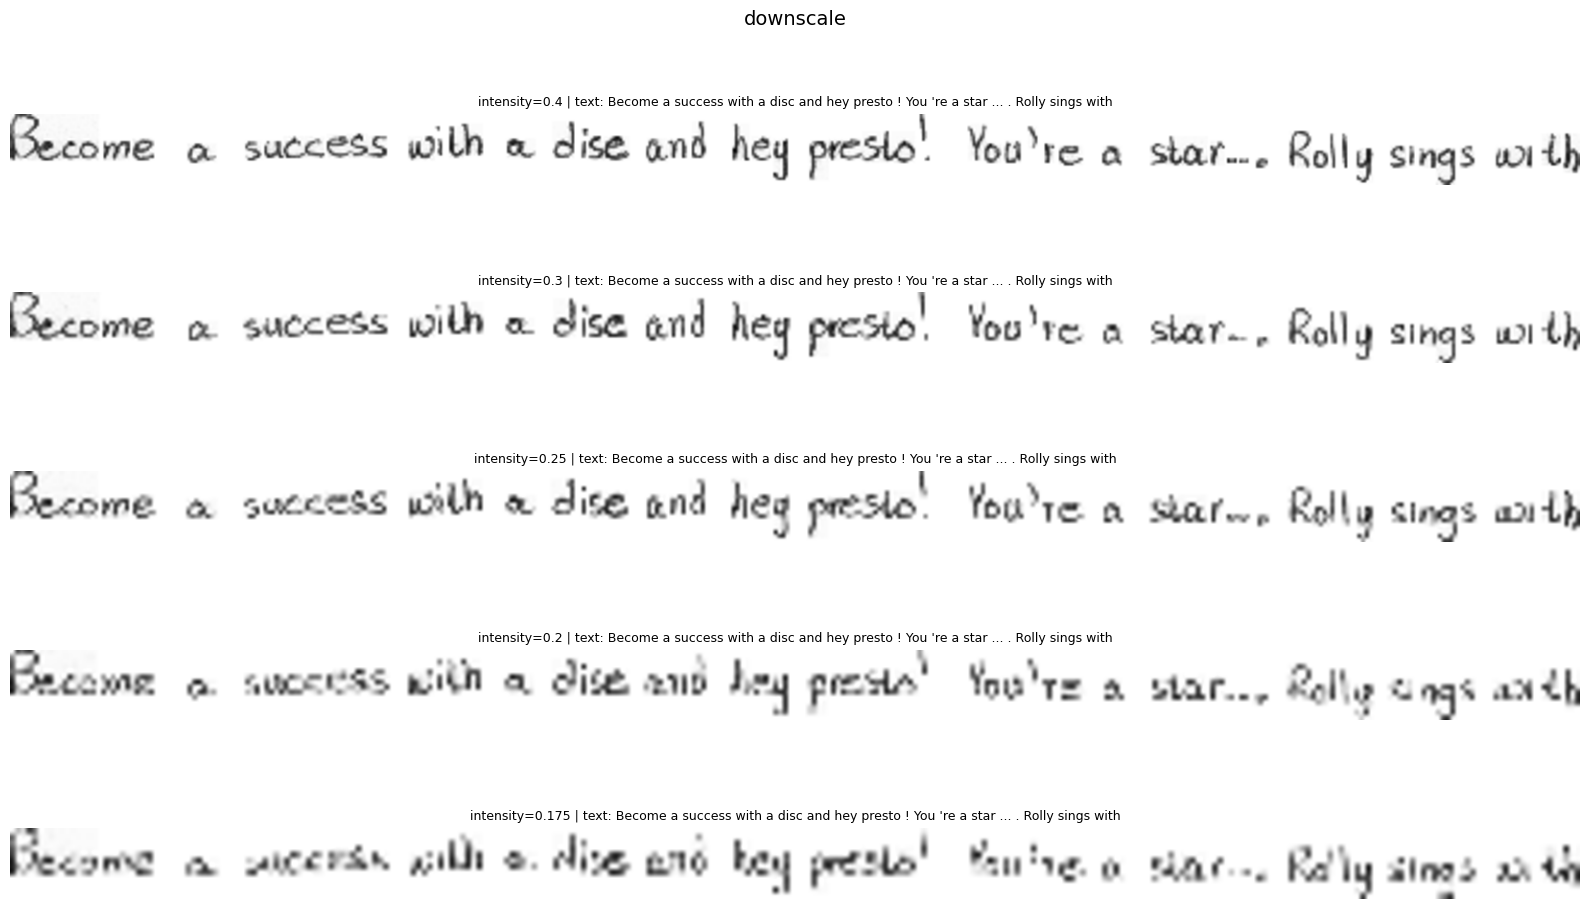

In [ ]:
# Downscaling
verify_and_display(method_name="downscale", intensities=[0.4, 0.3, 0.25, 0.2, 0.175])